# 06g — Barycenter methods compared on representation quality (G=28)

Kickoff **F** of the E→G→F arc (`.claude/plans/coordination-EFG-roadmap.md`).

The group-**discrimination** question is settled (`RESULTS_HANDOFF §12–§16`): symbol
**frequency dominates**, and E's §15 order-shuffle-null finds **0/15** order signals (every ΔAUC
95% CI brackets 0) — *which* actions occur and *how often*, not *in what order*. This notebook
scores the **other** axis: how faithfully each averaging method **represents** the group it
summarises. Success = representation quality, judged identically across methods via the
`{build, distance}` registry — not classification.

The centrepiece is the **Fused Gromov–Wasserstein (FGW) barycenter** (Vayer, Chapel, Flamary,
Tavenard, Courty, *ICML 2019* / *Algorithms 2020*; POT `ot.gromov.fgw_barycenters`). Its **α**
interpolates the symbol-frequency histogram (α→0, feature/Wasserstein) and intra-sequence
temporal structure (α→1, Gromov–Wasserstein) — one knob for a clean frequency↔structure
decomposition. **We do not tune α to win**: E's §15 already says structure should matter little,
so the honest question is whether α>0 buys anything on *representation* (it does not; see below).

Metrics (`smartflat.features.symbolic_barycenter.barycenter_quality`): rTWE within-group inertia
(common yardstick), native inertia, frequency fidelity (Wasserstein-on-`D_G`), temporal-structure
preservation (bigram), symbol entropy (the §12.3 mode-collapse lens), distinct-symbol and segment
counts, and FGW init-stability.

In [1]:
%load_ext autoreload
%autoreload 2
%matplotlib inline
import os
os.environ.setdefault('NUMBA_THREADING_LAYER', 'workqueue')  # fork-safe rTWE under nbconvert
import json
import numpy as np, pandas as pd, matplotlib.pyplot as plt
from IPython.display import display
from smartflat.utils.utils_io import get_data_root
from smartflat.features.symbolic_barycenter import vocab
from smartflat.features.symbolic_barycenter import visualization as viz
from smartflat.features.symbolic_barycenter.baselines import (
    default_baseline_methods, barycenter_mode_dba, barycenter_soft_mode_dba,
    barycenter_edit_median, barycenter_transition_matrix, barycenter_fgw,
    dist_rtwe, dist_edit, dist_transition, fgw_methods)
from smartflat.features.symbolic_barycenter.barycenter_quality import (
    score_barycenter_quality, quality_table, build_fgw_registry)
from smartflat.engine.distances._rtwe import rtwe_pairwise_distance
pd.set_option('display.width', 200, 'display.max_columns', 30)
plt.rcParams['figure.dpi'] = 110

OUT = os.path.join(get_data_root(), 'outputs', 'symbolic_barycenter', 'g28')
EXP = os.path.join(OUT, 'experiments'); os.makedirs(EXP, exist_ok=True)

# Hyperparameters (thesis G=28) and the shared length gate.
L, NU, LMBDA, MAX_ITER, RS = 128, 1e-4, 0.1, 10, 42
print('output dir:', EXP)

output dir: /Users/samperochon/github-repositories/smartflat/data/data-gold-final/outputs/symbolic_barycenter/g28/experiments


In [2]:
# Canonical G=28 cohort + ground cost via E's shared loaders (06c Cells 2-3).
# FGW and the lock-step methods need a rectangular length -> upsample to L=128 (the low end
# of 06c's L_SWEEP; gates the O(L^2) barycenter builds). Full L~5162 stays deferred.
df, X, labels = vocab.load_g28_cohort(upsample_to=L)
D_G = vocab.build_g28_ground_cost(); G = D_G.shape[0]
code_dict = json.load(open(os.path.join(OUT, 'category_codes.json')))
code_to_label = {int(v): k for k, v in code_dict.items()}

# One-time pairwise rTWE (needed by the k_medoid exemplar); ~seconds at L=128.
D_pw = rtwe_pairwise_distance(X.astype(np.float64), nu=NU, lmbda=LMBDA,
                             precomputed_distances=np.ascontiguousarray(D_G))
print('cohort:', df.groupby('pathologie').size().to_dict(), '| G =', G, '| X', X.shape)

cohort: {'HEALTHY': 24, 'RIL': 37, 'TBI': 59} | G = 28 | X (120, 128)


## (1) Method registry — the `{build, distance}` contract

Every method is scored **identically** by the harness. Native distances are each method's own
(rTWE for the alignment methods, Wasserstein for the histogram, edit for the median string,
Frobenius for the transition matrix).

**Length gating (mirrors 06c).** At L=128 the two embedding-space DTW baselines — `dba_dtw` and
`soft_dtw` (Petitjean 2011 / Cuturi–Blondel 2017, applied to the `D_G`-embedded real series) — are
**O(L²·G)** and cost ~130 s / group each; they are **gated out here** and left to a shorter-L or
later-session run. The tractable set below still covers the scientifically central comparison: the
paper's **TW-TWE mode-DBA** (`tw_twe_mode`), its soft variant (`shape_dba`), the frequency
histogram (`wasserstein`), the exemplar (`k_medoid`), lock-step voting (`majority_voting`), the
bigram-ordering barycenter (`transition`), the edit median, and **FGW** (`fgw_mds`, `fgw_onehot`).

In [3]:
base = default_baseline_methods(D_G, nu=NU, lmbda=LMBDA)
methods = {
    'wasserstein':     base['wasserstein'],       # symbol-frequency histogram (the winning baseline)
    'k_medoid':        base['k_medoid'],           # within-group rTWE exemplar
    'majority_voting': base['majority_voting'],    # lock-step per-position mode
    'transition':      {'build': lambda Xg, s: barycenter_transition_matrix(Xg, G),
                        'distance': lambda seq, b: dist_transition(seq, b)},
    'tw_twe_mode':     {'build': lambda Xg, s: barycenter_mode_dba(Xg, D_G, nu=NU, lmbda=LMBDA, max_iter=MAX_ITER),
                        'distance': lambda seq, b: dist_rtwe(seq, b, D_G, nu=NU, lmbda=LMBDA)},
    'shape_dba':       {'build': lambda Xg, s: barycenter_soft_mode_dba(Xg, D_G, nu=NU, lmbda=LMBDA, max_iter=MAX_ITER, random_state=s),
                        'distance': lambda seq, b: dist_rtwe(seq, b, D_G, nu=NU, lmbda=LMBDA)},
    'edit_median':     {'build': lambda Xg, s: barycenter_edit_median(Xg, n_alphabet=G),
                        'distance': lambda seq, b: dist_edit(seq, b)},
}
methods.update(fgw_methods(D_G, n_nodes=L, alpha=0.5, nu=NU, lmbda=LMBDA))  # fgw_mds, fgw_onehot (alpha=0.5)
print('GATED at L=128 (O(L^2 G)): dba_dtw, soft_dtw  (~130 s/group each)')
print('scored:', list(methods))

GATED at L=128 (O(L^2 G)): dba_dtw, soft_dtw  (~130 s/group each)
scored: ['wasserstein', 'k_medoid', 'majority_voting', 'transition', 'tw_twe_mode', 'shape_dba', 'edit_median', 'fgw_mds', 'fgw_onehot']


## (2) Methods × quality-metric table

Deterministic builders are scored with a single init (the two FGW methods are near-deterministic;
stability is quantified separately in §3). rTWE inertia is the common yardstick; it is `NaN` for
the histogram (`wasserstein`, no sequence) and the transition-matrix (`transition`) outputs, which
still report their native and frequency/structure metrics.

In [4]:
res = score_barycenter_quality(X, labels, methods, D_G, D_pairwise=D_pw,
                               n_inits=1, random_state=RS)
q = quality_table(res).drop(columns=['stability_inertia_rtwe', 'stability_histogram'])
q.to_csv(os.path.join(EXP, 'barycenter_quality_methods_L128.csv'))
# group-level entropy reference for the mode-collapse lens (~3.7-3.8 bits).
grp_H = np.mean([
    -(lambda p: (p[p>0]*np.log2(p[p>0])).sum())(np.bincount(X[labels==g].ravel(), minlength=G)/ (labels==g).sum()/L)
    for g in np.unique(labels)])
print(f'group-sequence entropy reference: ~{grp_H:.2f} bits')
display(q.round(3))

group-sequence entropy reference: ~3.78 bits


metric,inertia_rtwe,inertia_native,freq_fidelity,struct_preservation,entropy_bits,n_distinct,n_segments
method,,,,,,,
edit_median,46.006,79.148,0.090,2.590,3.536,16.667,57.667
fgw_mds,78.798,78.798,0.043,3.273,3.499,17.333,114.333
fgw_onehot,76.337,76.337,0.038,3.287,3.546,18.000,112.667
k_medoid,46.523,46.523,0.120,2.713,3.353,16.333,54.000
majority_voting,44.173,0.663,0.193,2.554,2.454,9.333,42.667
shape_dba,44.591,44.591,0.105,2.616,3.000,12.667,59.000
transition,NaN,2.845,NaN,0.000,NaN,NaN,NaN
tw_twe_mode,44.790,44.790,0.120,2.661,3.022,13.333,56.667
wasserstein,NaN,0.125,0.027,NaN,3.729,28.000,NaN


**Reading the table.**

- **Frequency fidelity** (Wasserstein-on-`D_G` to the group histogram; lower = better):
  `wasserstein` is best by construction, but **FGW is next** (`fgw_onehot` 0.038, `fgw_mds` 0.043)
  and **far ahead of the paper's `tw_twe_mode` (0.12)** and `majority_voting` (0.19). The alignment
  averagers distort the group frequency profile; FGW largely preserves it.
- **Entropy / mode-collapse** (group ≈ 3.7 bits): `wasserstein` ≈ 3.7 and **FGW ≈ 3.5** stay near
  the group level, while `tw_twe_mode` (3.0), `shape_dba` (3.0) and `majority_voting` (2.5)
  **collapse** — dropping minority-but-informative symbols (the §12.3 failure), also visible in
  `n_distinct` (28 → ~17 for FGW → ~13 for mode-DBA → 9 for majority voting).
- **rTWE inertia** (common yardstick; lower = better): the **alignment methods win** (`tw_twe_mode`
  ≈ 44.8, `majority_voting`/`shape_dba`/`k_medoid` ≈ 44–46) because they optimise this warped
  geometry directly; **FGW is worst** (≈ 78) — it optimises its *own* objective, not rTWE. An
  honest tradeoff, reported both ways: FGW buys frequency fidelity + anti-collapse at the cost of
  rTWE compactness.
- **Temporal-structure preservation** (Frobenius to the group-mean bigram matrix): `transition` is
  the mean (≈ 0); the sequence methods sit ≈ 2.6, FGW slightly higher (≈ 3.3) — GW structure is a
  *global* geometry, not the bigram statistic this metric reads.

## (3) FGW init-stability

Variance of the barycenter across random POT initialisations (deterministic builders are 0 by
construction, so only the FGW methods are informative).

In [5]:
stab = score_barycenter_quality(X, labels, fgw_methods(D_G, n_nodes=L, alpha=0.5, nu=NU, lmbda=LMBDA),
                                D_G, n_inits=3, random_state=RS)
display(quality_table(stab)[['stability_inertia_rtwe', 'stability_histogram']].round(4))
print('rTWE-inertia std is ~2% of the ~78 inertia level; histogram std ~1e-3 -> FGW is init-stable.')

metric,stability_inertia_rtwe,stability_histogram
method,,
fgw_mds,1.6686,0.0028
fgw_onehot,1.2989,0.0001


rTWE-inertia std is ~2% of the ~78 inertia level; histogram std ~1e-3 -> FGW is init-stable.


## (4) FGW α-decomposition — the frequency↔structure knob

Sweep α from ≈0 (feature/frequency) to 1 (Gromov–Wasserstein structure) for **both** encodings
(**no cherry-picked α** — the full sweep is shown). Consistency check: at α→0 the FGW barycenter
should approach the frequency histogram (`wasserstein` fidelity ≈ 0.027).

In [6]:
ALPHAS = [1e-3, 0.25, 0.5, 0.75, 1.0]
sweep = build_fgw_registry(D_G, alphas=ALPHAS, n_nodes=L, encodings=('mds', 'onehot'),
                           nu=NU, lmbda=LMBDA)
resa = score_barycenter_quality(X, labels, sweep, D_G, n_inits=1, random_state=7)
qa = quality_table(resa)[['freq_fidelity', 'struct_preservation', 'entropy_bits',
                          'inertia_rtwe', 'n_segments']]
qa.to_csv(os.path.join(EXP, 'barycenter_quality_fgw_alpha.csv'))
display(qa.round(3))

metric,freq_fidelity,struct_preservation,entropy_bits,inertia_rtwe,n_segments
method,,,,,
fgw_mds_a0.001,0.040,3.561,3.590,78.422,113.000
fgw_mds_a0.25,0.040,3.159,3.521,79.249,117.000
fgw_mds_a0.5,0.043,3.260,3.518,77.504,115.667
fgw_mds_a0.75,0.045,3.124,3.531,78.606,114.000
fgw_mds_a1,0.259,3.180,2.973,81.342,107.333
fgw_onehot_a0.001,0.037,3.453,3.619,78.045,116.667
fgw_onehot_a0.25,0.038,3.378,3.589,78.782,112.333
fgw_onehot_a0.5,0.037,3.341,3.544,79.760,117.000
fgw_onehot_a0.75,0.036,3.397,3.527,78.160,115.000


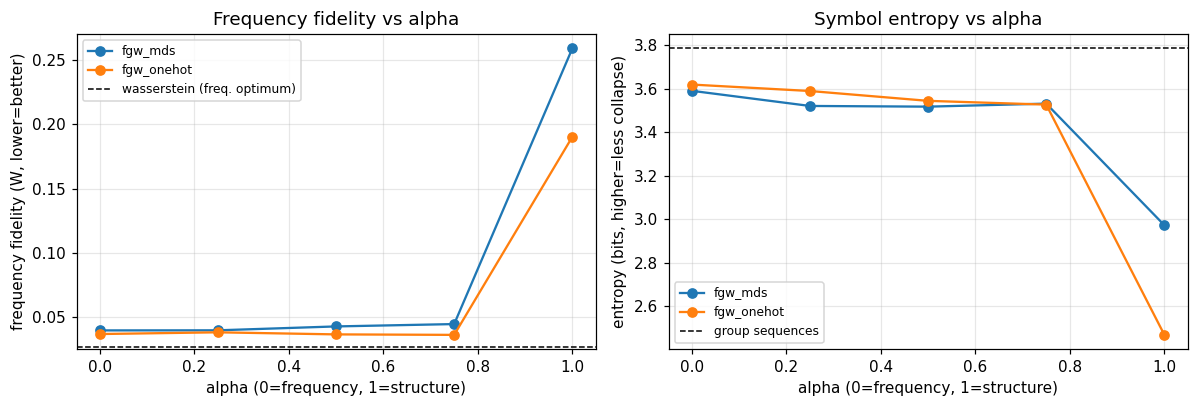

In [7]:
# Figure: frequency fidelity and entropy vs alpha (both encodings).
fig, ax = plt.subplots(1, 2, figsize=(11, 3.8))
for enc, col in [('mds', 'tab:blue'), ('onehot', 'tab:orange')]:
    ff = [qa.loc[f'fgw_{enc}_a{a:g}', 'freq_fidelity'] for a in ALPHAS]
    he = [qa.loc[f'fgw_{enc}_a{a:g}', 'entropy_bits'] for a in ALPHAS]
    ax[0].plot(ALPHAS, ff, 'o-', color=col, label=f'fgw_{enc}')
    ax[1].plot(ALPHAS, he, 'o-', color=col, label=f'fgw_{enc}')
ax[0].axhline(q.loc['wasserstein', 'freq_fidelity'], ls='--', color='k', lw=1,
              label='wasserstein (freq. optimum)')
ax[0].set(xlabel='alpha (0=frequency, 1=structure)', ylabel='frequency fidelity (W, lower=better)',
          title='Frequency fidelity vs alpha')
ax[1].axhline(grp_H, ls='--', color='k', lw=1, label='group sequences')
ax[1].set(xlabel='alpha (0=frequency, 1=structure)', ylabel='entropy (bits, higher=less collapse)',
          title='Symbol entropy vs alpha')
for a in ax: a.legend(fontsize=8); a.grid(alpha=0.3)
fig.tight_layout(); fig.savefig(os.path.join(EXP, 'fgw_alpha_decomposition.png'), dpi=150,
                                bbox_inches='tight')
display(fig); plt.close(fig)   # display the Figure object so nbconvert embeds it under agg

**Reading the α-decomposition.** For **α ≤ 0.75** frequency fidelity holds near the frequency
optimum (≈ 0.04) and entropy stays near the group level (≈ 3.5 bits): FGW behaves like a
frequency-faithful average, and **α→0 approaches the `wasserstein` histogram** — the nested
special case (POT documents `0<α<1`; the α≈0 anchor confirms it empirically). At **α = 1**
(structure-only Gromov–Wasserstein) both **degrade sharply** — frequency fidelity jumps to
0.19–0.26 and entropy re-collapses to 2.5–3.0 bits. So adding *pure* temporal structure does **not**
improve the group representative; it *hurts* it. This is exactly what E's §15 predicts: the
discriminative and representational content is in frequency, not global order — the α knob is
**understood, not tuned to win**.

## (5) Per-method barycenter chronograms (degeneracy eyeballing)

One HEALTHY / TBI / RIL barycenter per method (cf. 06c Cell 11), all sharing a single categorical
colormap. Watch for **mode-collapse** (large flat blocks of one colour — `majority_voting`,
`tw_twe_mode`) versus the busier, more symbol-diverse FGW strips.

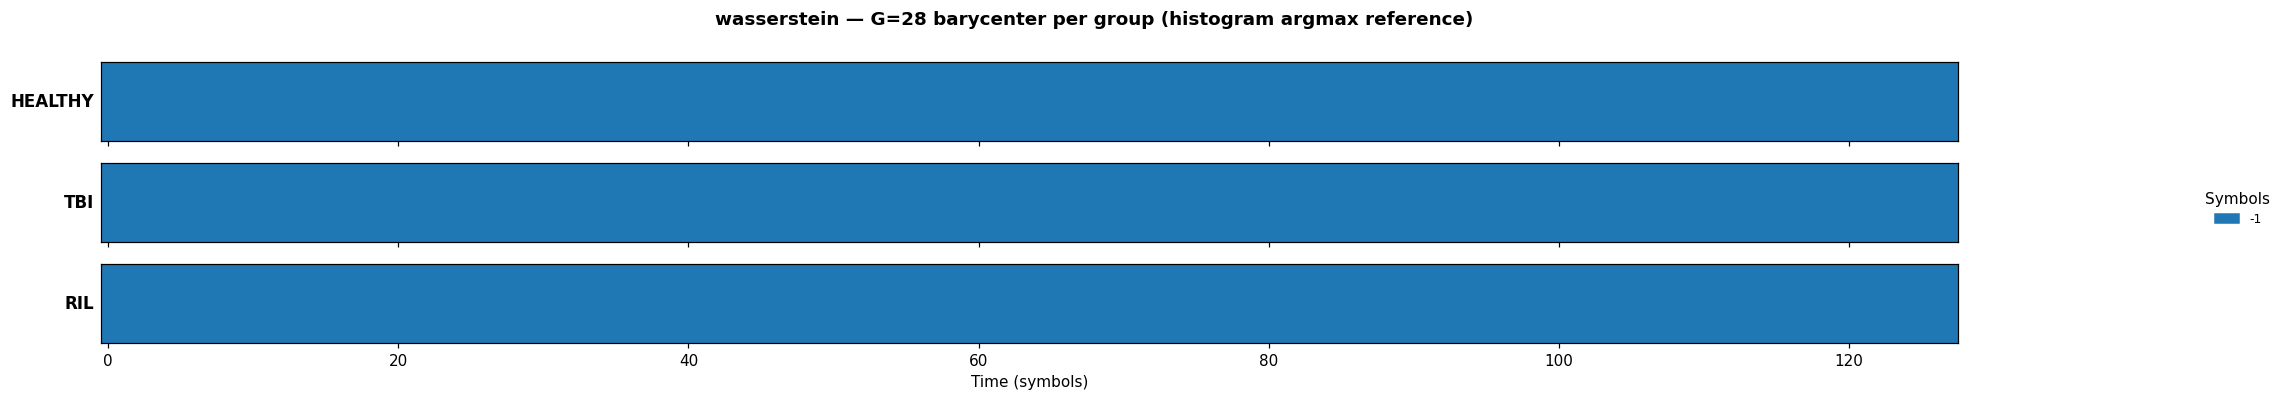

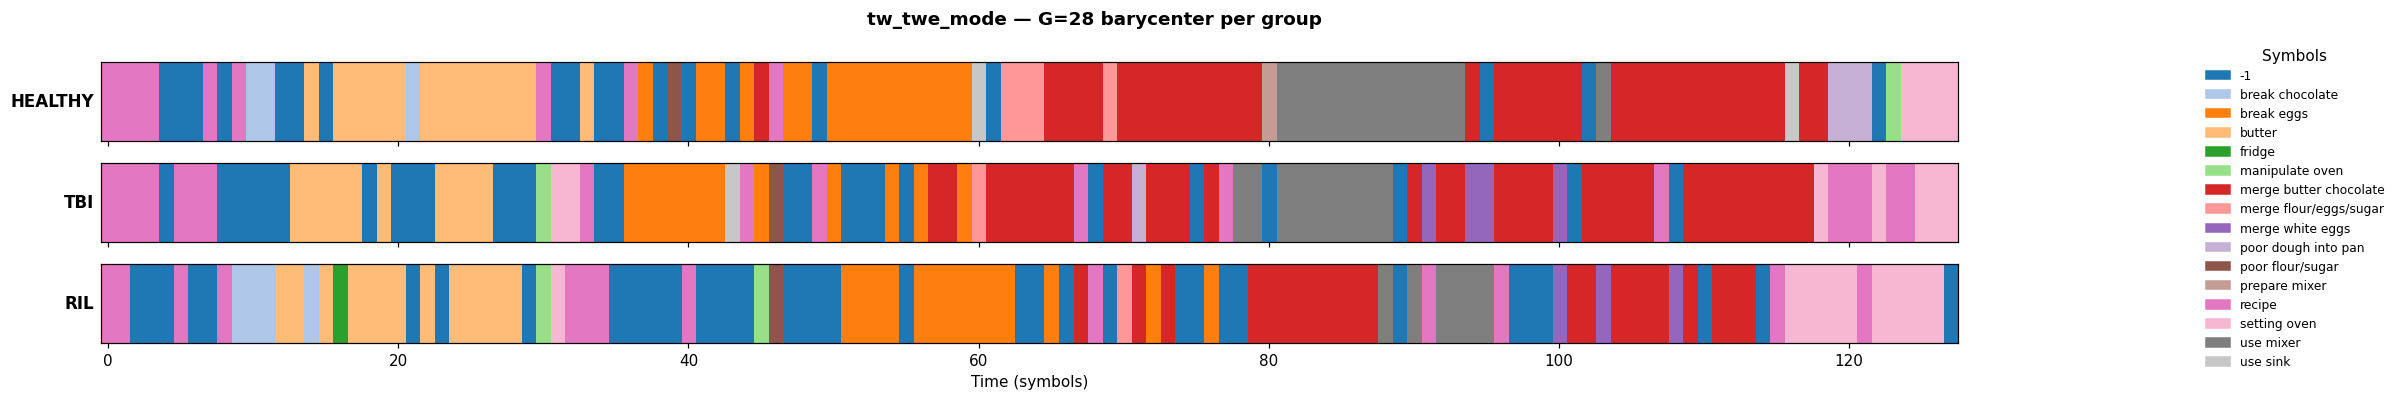

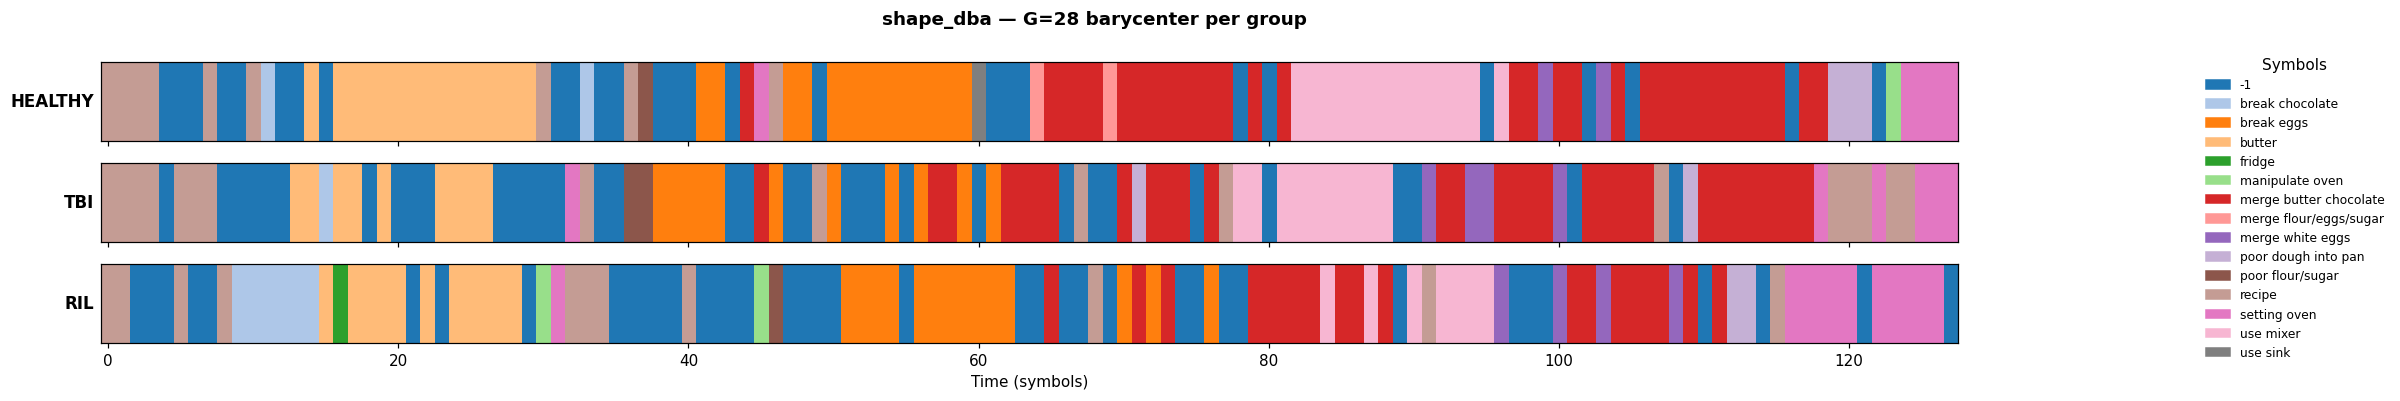

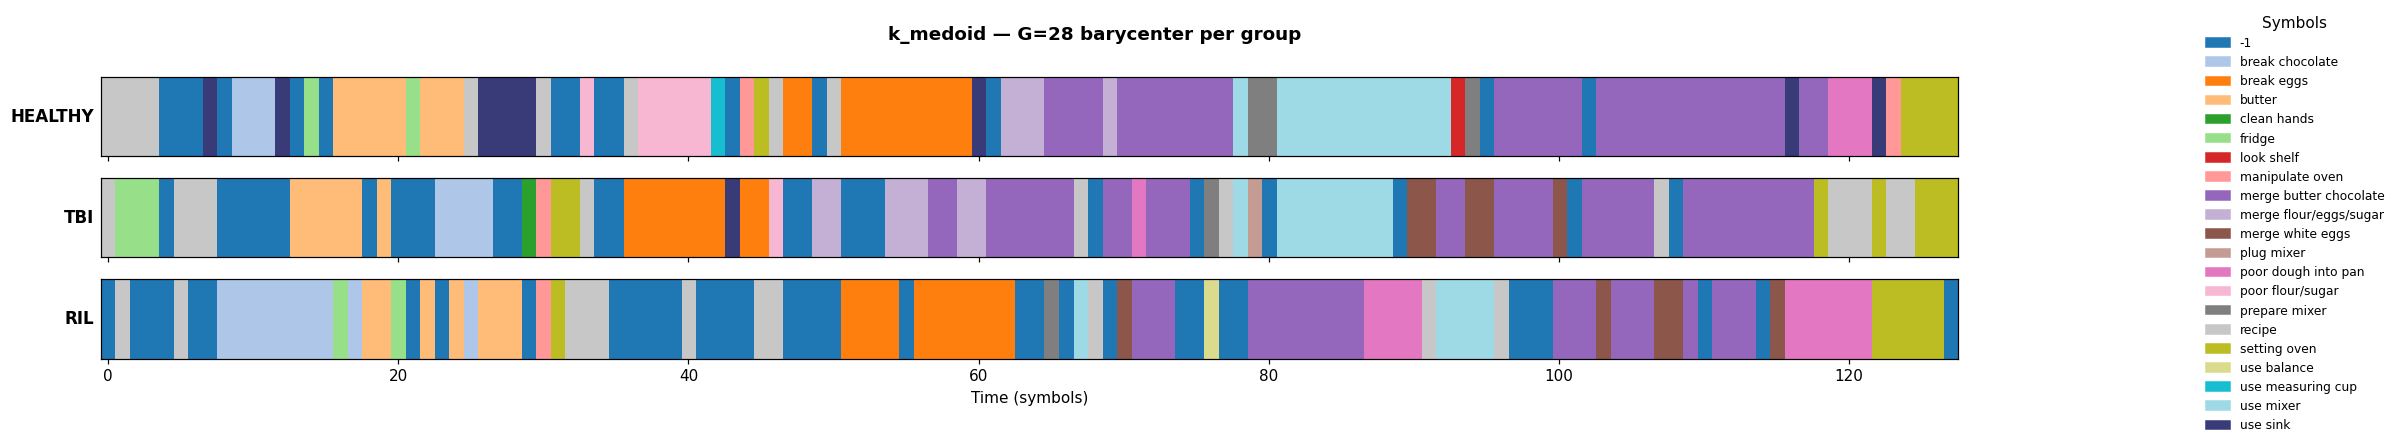

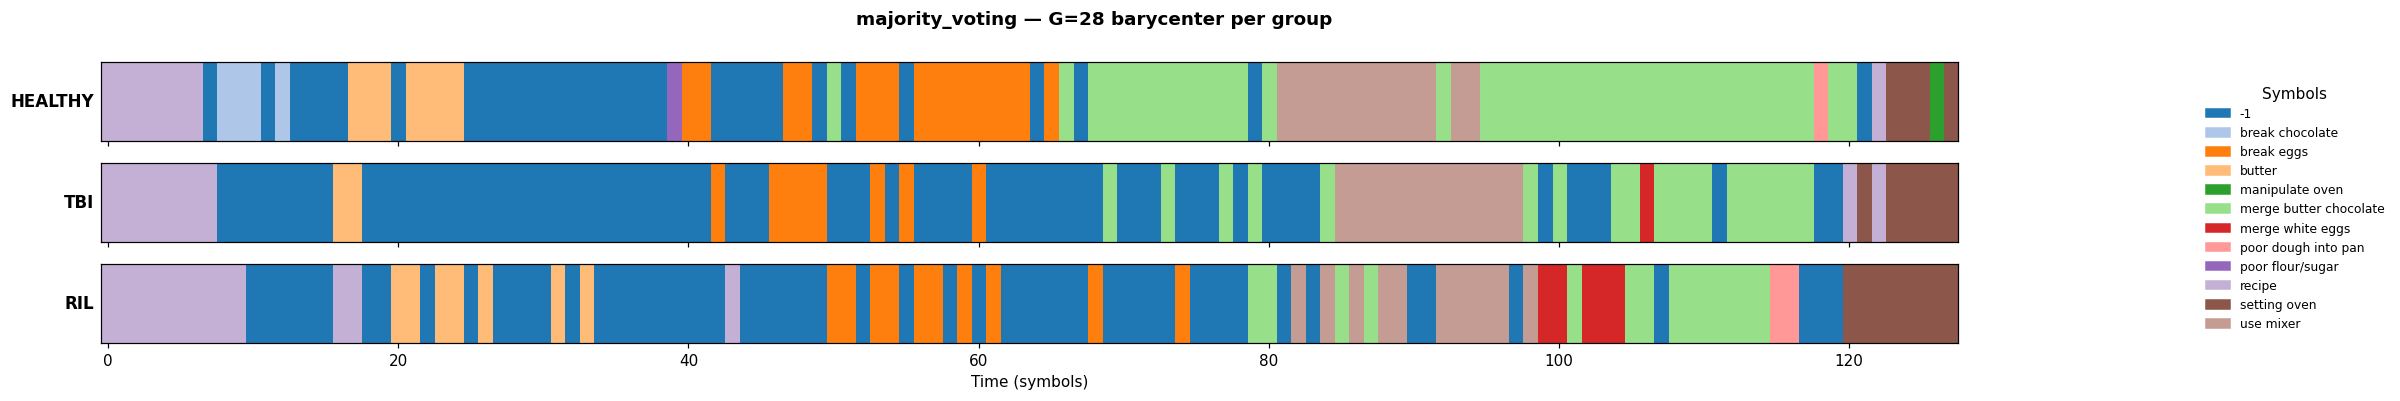

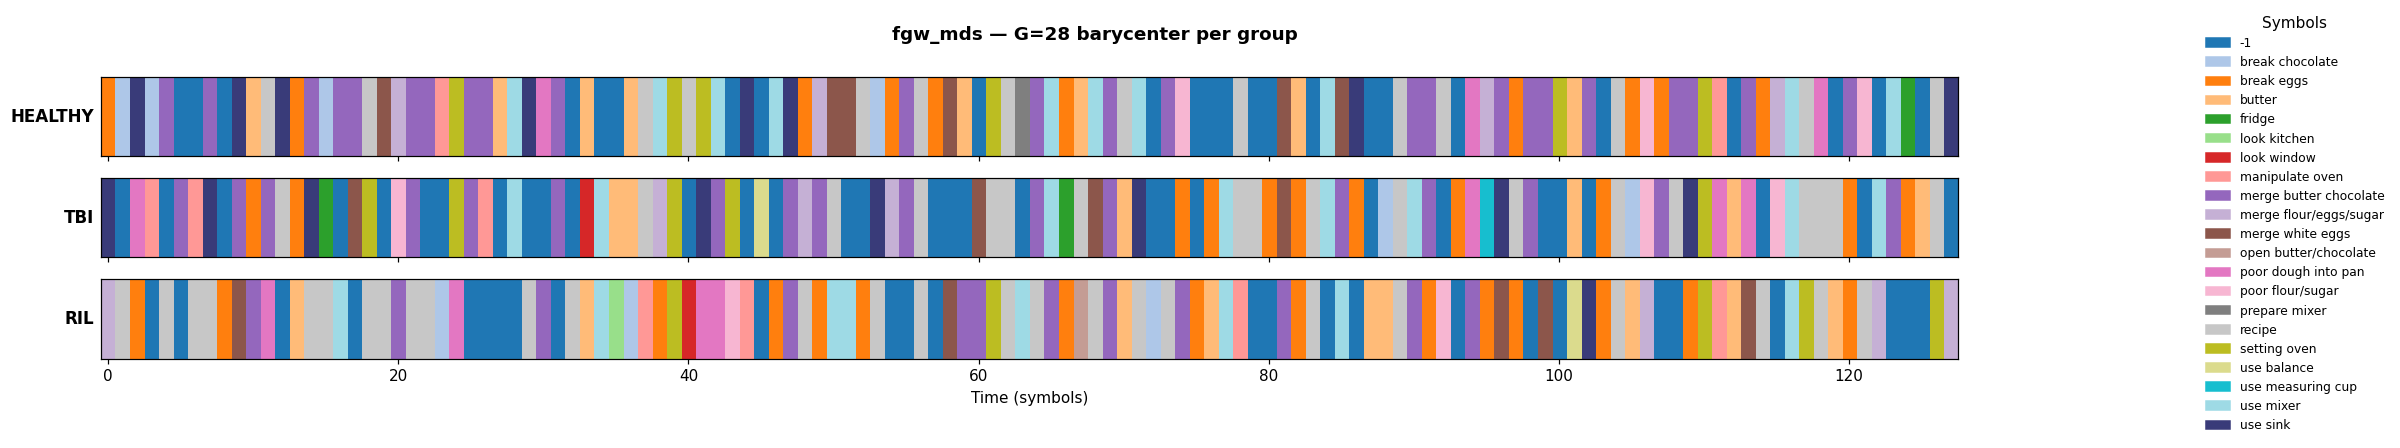

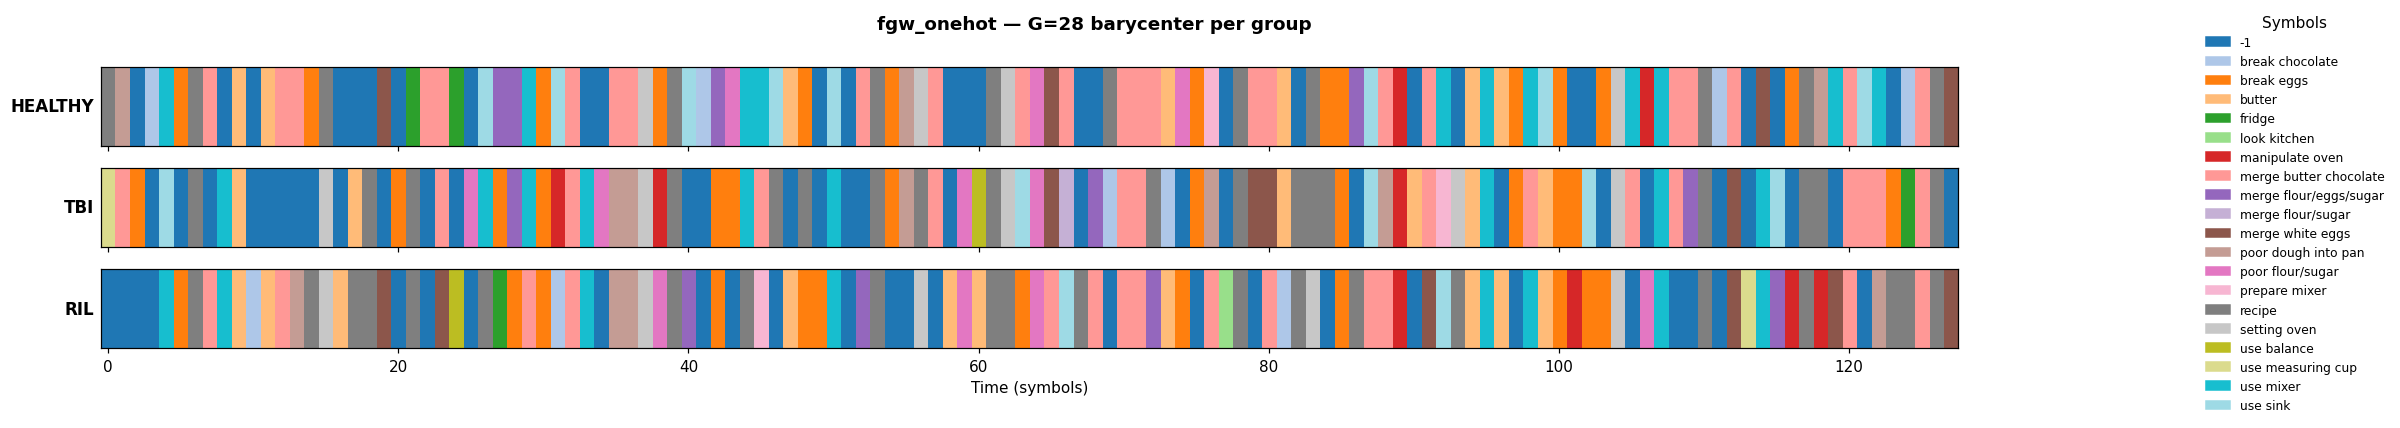

In [8]:
CHRONO_METHODS = ['wasserstein', 'tw_twe_mode', 'shape_dba', 'k_medoid', 'majority_voting',
                  'fgw_mds', 'fgw_onehot']
groups = ['HEALTHY', 'TBI', 'RIL']
# wasserstein returns a histogram (no sequence) -> render its most-probable symbol repeated,
# purely for a visual reference strip (marked in the title).
def _as_seq(name, spec, Xg):
    if spec.get('kind') == 'medoid':
        idx = np.arange(len(Xg))[np.argmin(rtwe_pairwise_distance(
            Xg.astype(np.float64), nu=NU, lmbda=LMBDA,
            precomputed_distances=np.ascontiguousarray(D_G)).sum(1))]
        return np.asarray(Xg[idx]).astype(int)
    b = np.asarray(spec['build'](Xg, RS))
    if b.ndim == 2:            # transition matrix -> skip (no sequence)
        return None
    if b.ndim == 1 and b.shape[0] == G and np.issubdtype(b.dtype, np.floating):
        return np.full(L, int(np.argmax(b)), dtype=int)   # histogram -> argmax reference strip
    return b.astype(int)

for name in CHRONO_METHODS:
    spec = methods[name]
    barys = {g: _as_seq(name, spec, X[labels == g].astype(int)) for g in groups}
    barys = {g: v for g, v in barys.items() if v is not None}
    tag = ' (histogram argmax reference)' if name == 'wasserstein' else ''
    fig = viz.plot_cohort_barycenters(barys, groups=list(barys), code_to_label=code_to_label,
                                      title=f'{name} — G=28 barycenter per group{tag}')
    fig.savefig(os.path.join(EXP, f'chronogram_{name}.png'), dpi=150, bbox_inches='tight')
    display(fig); plt.close(fig)   # display the Figure so nbconvert embeds it under agg

## Summary (→ `RESULTS_HANDOFF_barycenters.md` §17)

On representation quality at G=28 (L=128):

1. **FGW is the most frequency-faithful, least mode-collapsed** structured averager — it nearly
   matches the `wasserstein` histogram on frequency fidelity (0.038–0.043 vs 0.027) and symbol
   entropy (≈ 3.5 vs group ≈ 3.7), while the paper's `tw_twe_mode` and `majority_voting` collapse
   to ≈ 3.0 / 2.5 bits and 0.12 / 0.19 fidelity.
2. **The alignment methods (incl. `tw_twe_mode`) win the rTWE-inertia yardstick** (≈ 44 vs FGW's
   ≈ 78): they are the most *compact* summaries in the warped geometry they optimise. Which method
   is 'best' depends on the fidelity axis — an honest, reportable tradeoff, not a single winner.
3. **FGW's α-decomposition confirms E's §15**: frequency fidelity and entropy are preserved for
   α ≤ 0.75 and degrade at α = 1 (structure-only). Structure-awareness does not improve the group
   representative — the knob is understood, not tuned. α→0 recovers the frequency histogram as the
   nested special case.

Deferred to later arc sessions (per the plan): Soft-DTW / SSG, ShapeDBA (off-label), and a
profile-HMM / progressive-MSA positional consensus; plus the O(L²·G) `dba_dtw` / `soft_dtw`
baselines at a tractable length.